<a href="https://colab.research.google.com/github/Perla-Soleith/ProyectoFinalProbabilidad/blob/main/Pr%C3%A1cticaFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Probabilidad y estadistica***

#### 2YY

### Unidad VI Proyecto Final

### 25 de Mayo de 2026

### **INTEGRANTES**



### Perla Soleith Moreno Pérez
### Diego Rodriguez Rochin

### **Docente**
###José Gabriel Rodriguez Rivas
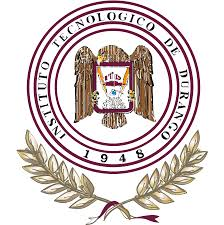

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:

from google.colab import drive
drive.mount('/content/drive')

Ruta = ('/content/drive/MyDrive/covid19.csv')

df = pd.read_csv(Ruta, low_memory=False)
df = df.sample(frac=0.1, random_state=42)   # Comentar/borrar esta linea para usar todos los datos


#hay que corregir todo lo de los comebntario tambien


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#***Estadística Descriptiva***

♦ Número de casos positivos, negativos y pendientes de resultado

In [25]:
print("--- ESTADÍSTICA DESCRIPTIVA ---")

# 1. Número de casos positivos, negativos y pendientes

print("\nResultado del diagnóstico:")
print(df['RESULTADO_ANTIGENO'].value_counts())



--- ESTADÍSTICA DESCRIPTIVA ---

Resultado del diagnóstico:
RESULTADO_ANTIGENO
Negativo     585622
Pendiente    501323
Positivo     176474
Name: count, dtype: int64


♦ Número de pacientes hospitalizados y ambulatorios

In [26]:
# 2. Número de pacientes hospitalizados y ambulatorios

print("\nTipo de paciente (Hospitalizado / Ambulatorio):")
print(df['TIPO_PACIENTE'].value_counts())




Tipo de paciente (Hospitalizado / Ambulatorio):
TIPO_PACIENTE
Ambulatorio      1155073
Hospitalizado     108346
Name: count, dtype: int64


♦ Cuántas pacientes estaban embarazadas


In [27]:
# 3. Cuántas pacientes estaban embarazadas

print("\nPacientes embarazadas:")
print(df['EMBARAZO'].value_counts())




Pacientes embarazadas:
EMBARAZO
No                 648320
No aplica          598417
Si                  12334
Se ignora            4345
No especificado         3
Name: count, dtype: int64


♦ Cuántos son indígenas

In [28]:
# 4. Cuántos son indígenas
print("\nPacientes indígenas:")
print(df['INDIGENA'].value_counts())


Pacientes indígenas:
INDIGENA
No                 366679
No especificado     16688
Si                   3457
Name: count, dtype: int64


###♦ Visualizaciones

♦ Grafica de barras por estado

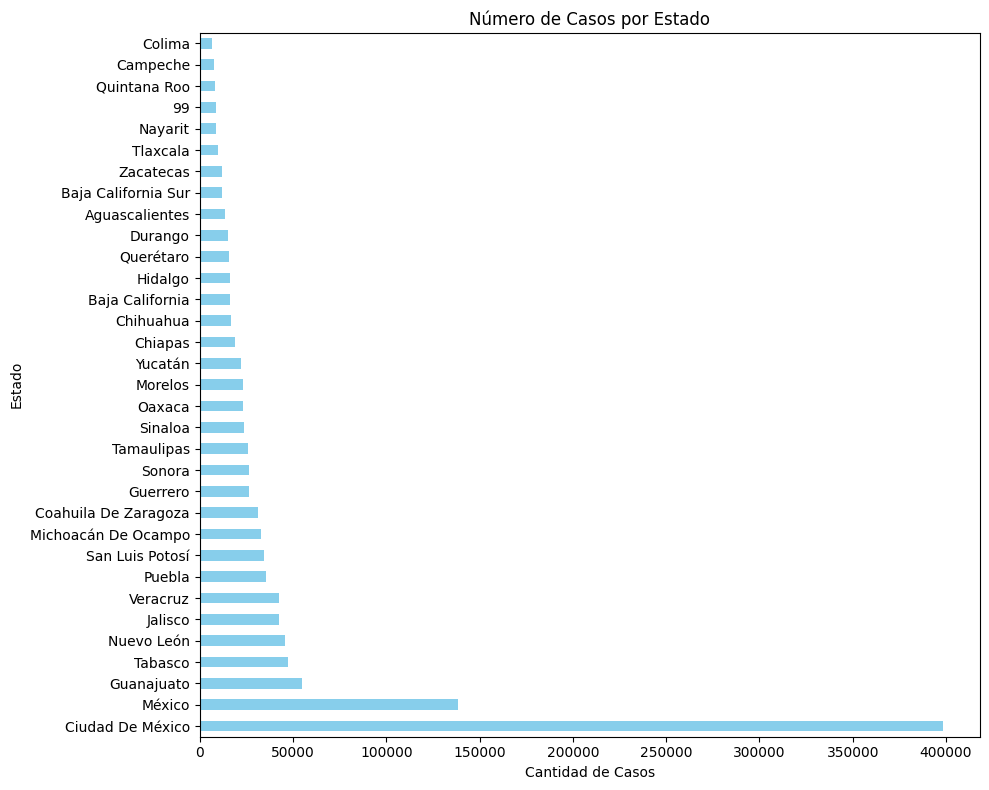

'plt.pyplot.hist(df.ENTIDAD_NAC, bins = 11)\nplt.pyplot.title("Histograma Edad pruebas COVID")\n#plt.pyplot.axvline(media, color=\'y\', linestyle=\'dashed\', linewidth=2, label=f\'Media={media:.2f}\')\nplt.pyplot.xlabel("Edad")\nplt.pyplot.ylabel("Frecuencia")'

In [15]:
# Visualizaciones

plt.figure(figsize=(10, 8))
# Cambia 'ENTIDAD_RES' por la columna que represente los estados en tu dataset
df['ENTIDAD_NAC'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Número de Casos por Estado')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()
'''plt.pyplot.hist(df.ENTIDAD_NAC, bins = 11)
plt.pyplot.title("Histograma Edad pruebas COVID")
#plt.pyplot.axvline(media, color='y', linestyle='dashed', linewidth=2, label=f'Media={media:.2f}')
plt.pyplot.xlabel("Edad")
plt.pyplot.ylabel("Frecuencia")'''

♦ Histograma por edad

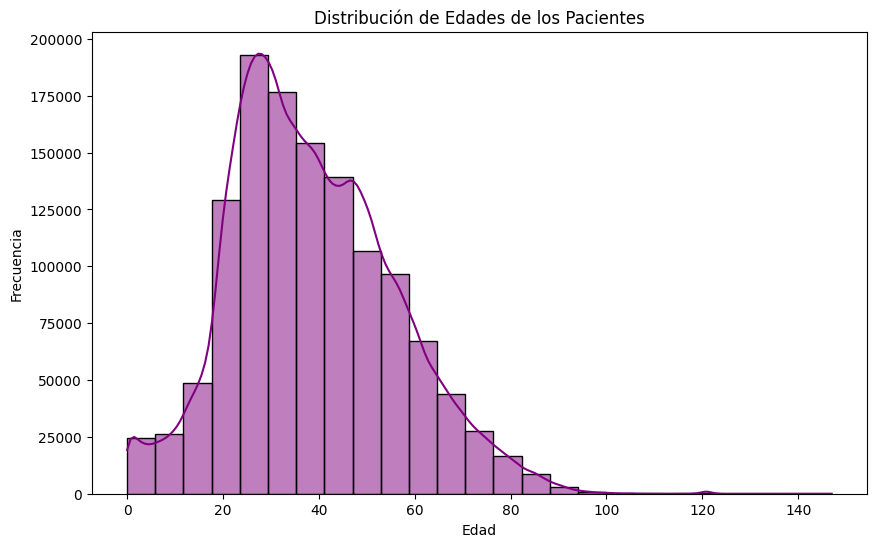

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['EDAD'], bins=25, kde=True, color='purple')
plt.title('Distribución de Edades de los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

♦ Gráfico por fecha para mostrar la evolución de casos.

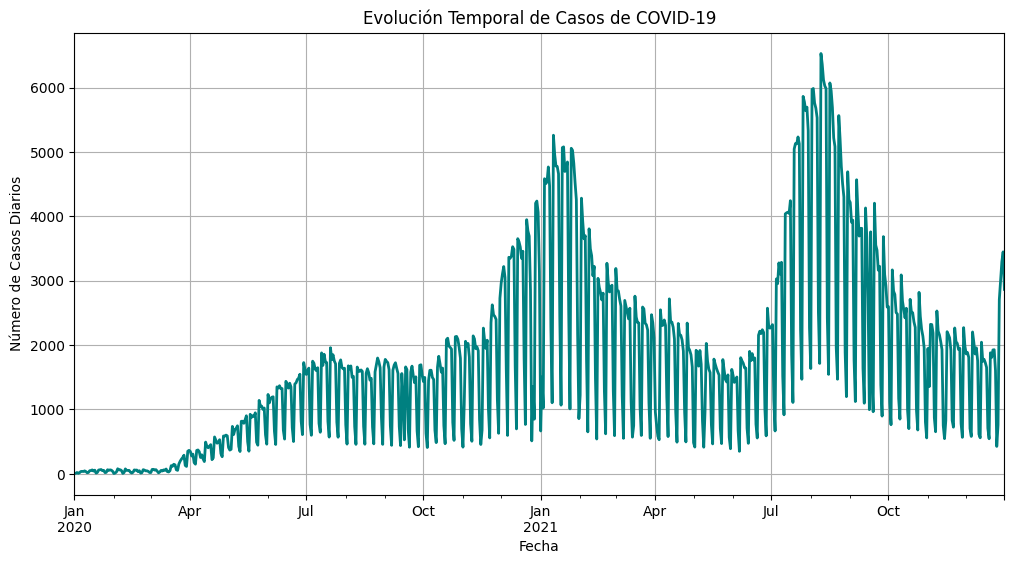

In [17]:
# Primero asegurémonos de que la columna de fecha sea de tipo datetime
df['FECHA_INGRESO'] = pd.to_datetime(df['FECHA_INGRESO'])

# Agrupamos los casos por fecha
casos_por_fecha = df.groupby('FECHA_INGRESO').size()

plt.figure(figsize=(12, 6))
casos_por_fecha.plot(kind='line', color='teal', linewidth=2)
plt.title('Evolución Temporal de Casos de COVID-19')
plt.xlabel('Fecha')
plt.ylabel('Número de Casos Diarios')
plt.grid(True)
plt.show()

♦ Gráfico por sexo y resultado.

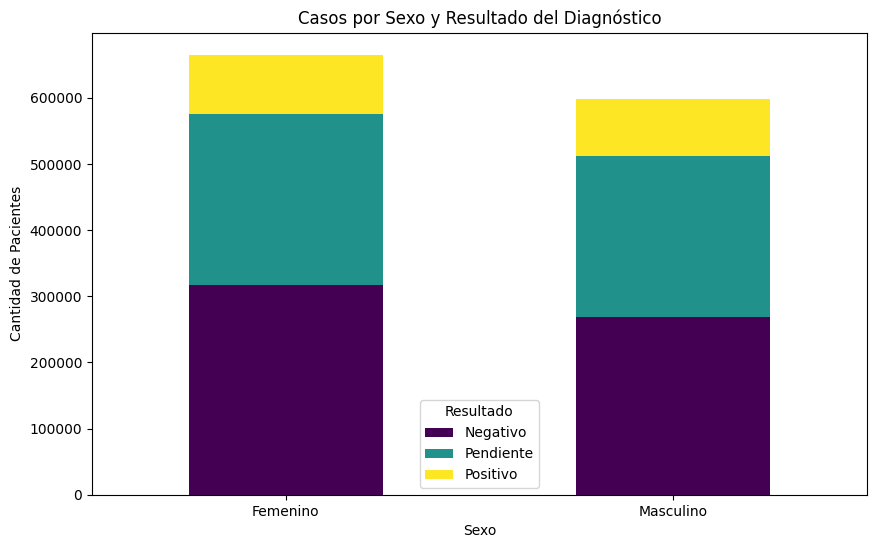

In [18]:
# Creamos una tabla cruzada (cross-tabulation) entre Sexo y RESULTADO_ANTIGENO
tabla_sexo_resultado = pd.crosstab(df['SEXO'], df['RESULTADO_ANTIGENO'])

tabla_sexo_resultado.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Casos por Sexo y Resultado del Diagnóstico')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(rotation=0)
plt.legend(title='Resultado')
plt.show()

♦ Gráfico por tipo de paciente

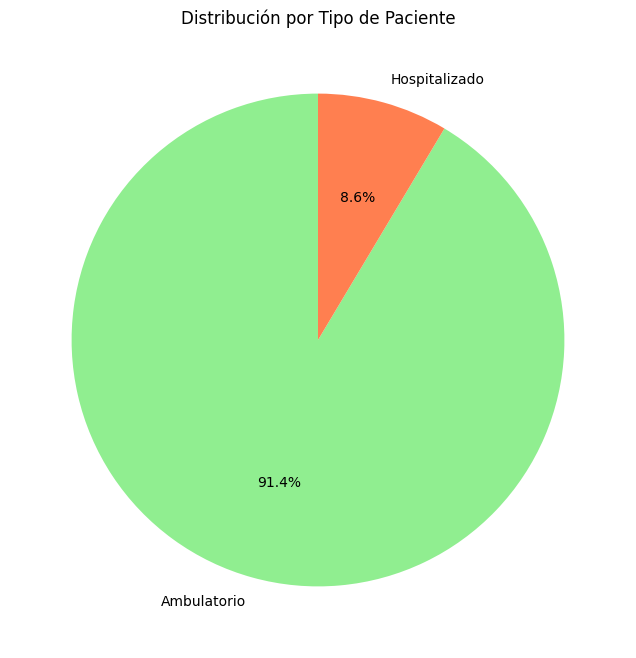

In [19]:
plt.figure(figsize=(8, 8))

df['TIPO_PACIENTE'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'coral'])
plt.title('Distribución por Tipo de Paciente')
plt.ylabel('') # Elimina el texto vertical del nombre de la columna
plt.show()

♦ Gráfico por comorbilidad

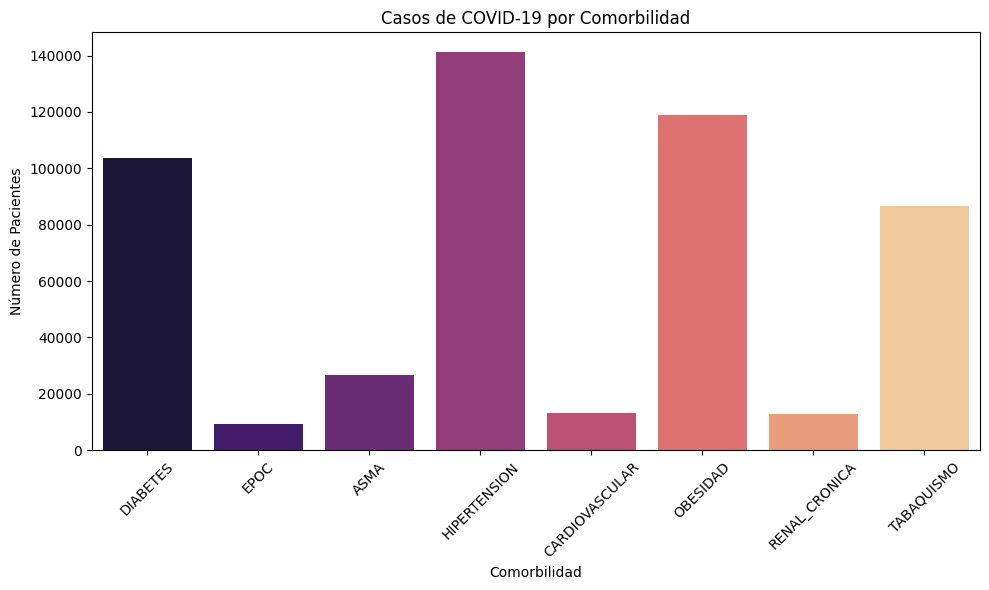

In [20]:
comorbilidades = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO']

# Contamos cuántos pacientes tienen 'Si' en cada comorbilidad
conteos = [df[df[c] == 'Si'].shape[0] for c in comorbilidades]

plt.figure(figsize=(10, 6))
sns.barplot(x=comorbilidades, y=conteos, palette='magma', hue=comorbilidades, legend=False)
plt.title('Casos de COVID-19 por Comorbilidad')
plt.xlabel('Comorbilidad')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#***Probabilidades por Comorbilidad e interpretación estadística***

In [24]:

#(el TIP)

comorbilidades = ['DIABETES', 'EPOC', 'ASMA', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESIDAD',
     'RENAL_CRONICA', 'TABAQUISMO']


#lo del total general de casos
total_general = len(df)
print(f"Total general de registros analizados: {total_general}\n")

#PROBABILIDAD SIMPLEEE

prob_simples = {}
for comorbilidad in comorbilidades:   #eto es para sacar lo del tip, de prob. por comorbilida con un for

    total_comorbilidad = (df[comorbilidad] == 'Si').sum()
    probabilidad = total_comorbilidad / total_general
    prob_simples[comorbilidad] = probabilidad

    print(f"Probabilidad simple de {comorbilidad}: {probabilidad:.2f} ({probabilidad * 100:.2f}%)")

Total general de registros analizados: 1263419

Probabilidad simple de DIABETES: 0.08 (8.20%)
Probabilidad simple de EPOC: 0.01 (0.72%)
Probabilidad simple de ASMA: 0.02 (2.10%)
Probabilidad simple de HIPERTENSION: 0.11 (11.17%)
Probabilidad simple de CARDIOVASCULAR: 0.01 (1.04%)
Probabilidad simple de OBESIDAD: 0.09 (9.40%)
Probabilidad simple de RENAL_CRONICA: 0.01 (1.01%)
Probabilidad simple de TABAQUISMO: 0.07 (6.86%)
